In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('datafinal.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [22]:
print(df.tail())

             Дата  Склад   Контрагент Номенклатура  Количество
298028 2018-08-29      3  address_112    product_2           3
298029 2018-08-29      3  address_112    product_3           3
298030 2018-08-29      3  address_112    product_4           2
298031 2018-08-29      3  address_112    product_5           1
298032 2018-08-29      3  address_112   product_22           2


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Проверяем формат столбцов

In [11]:
df['Дата'] = pd.to_datetime(df['Дата'])

Сразу переведем столбец "Дата" в правильный формат

In [6]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

Сгруппируйте данные по дате, посчитайте количество продаж

In [7]:
grouped_df.head()

,Дата,Количество
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


Вывести несколько первых строк сгруппированных данных

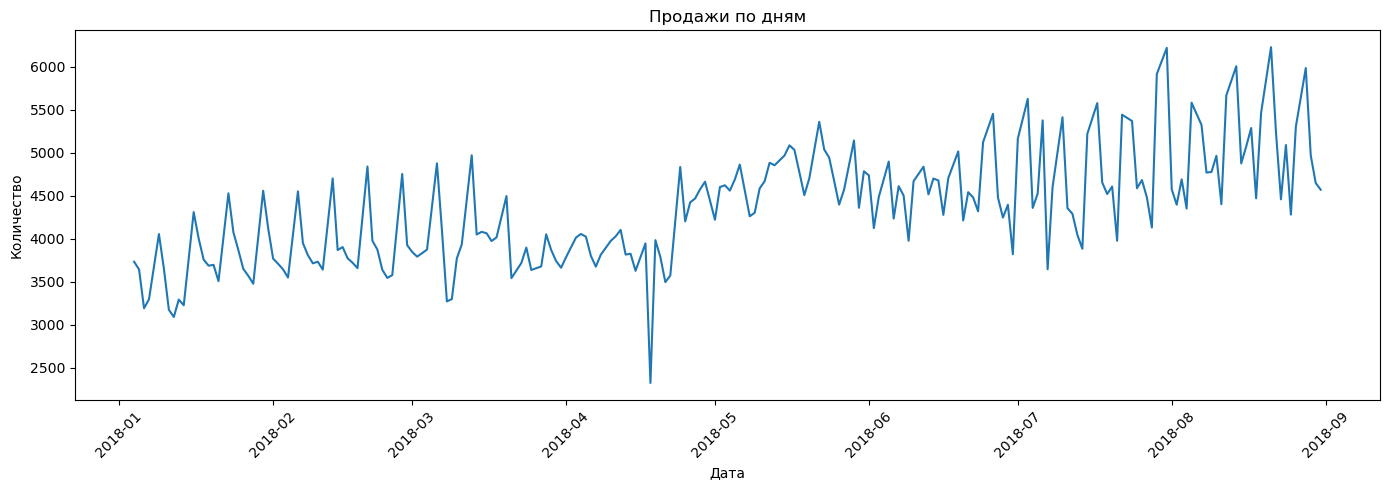

In [15]:
plt.figure(figsize=(14, 5))
plt.plot(grouped_df['Дата'], grouped_df['Количество'])
plt.title('Продажи по дням')
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Нарисуйте график продаж у `grouped_df`

На графике отображена динамика ежедневных продаж за период с января 2018 года.
Значения количества колеблются примерно в диапазоне 2000–6000 единиц в день.
Наблюдается нестабильная, волнообразная динамика без выраженного тренда роста или падения.
Присутствуют заметные пики и резкие провалы, что может свидетельствовать о сезонности,
выходных днях или разовых крупных закупках. Некоторые дни полностью отсутствуют в данных.

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [18]:
max_sales_row = df[df['Количество'] == df['Количество'].max()]
print(max_sales_row)

             Дата  Склад   Контрагент Номенклатура  Количество
218822 2018-06-28      1  address_208    product_0         200


Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [21]:
df = df[df['Склад'] == 3]
df = df[df['Дата'].dt.dayofweek == 2]
df = df[df['Дата'].dt.month.isin([6, 7, 8])]
grouped = df.groupby('Номенклатура')['Количество'].sum()
top_product = grouped.idxmax()
print(f"Топовый товар по продажам по средам за июнь, июль, август у 3 склада: {top_product}")

Топовый товар по продажам по средам за июнь, июль, август у 3 склада: product_1


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [25]:
pip install xlrd

Note: you may need to restart the kernel to use updated packages.


In [26]:
df_weather = pd.read_excel('weatherfinal.xls')

In [27]:
df_weather.head()

,Местное время в Астане,T
0,31.08.2018 23:00,8.2
1,31.08.2018 20:00,9.6
2,31.08.2018 17:00,11.3
3,31.08.2018 14:00,12.3
4,31.08.2018 11:00,13.2


In [29]:
df_weather = df_weather.rename(columns={'Местное время в Астане': 'Дата'})
df_weather['Дата'] = pd.to_datetime(df_weather['Дата'])
df_weather['Дата'] = df_weather['Дата'].dt.normalize()
df_weather = df_weather.groupby('Дата')['T'].mean().reset_index()
print(df_weather.head())

        Дата        T
0 2018-01-01  -9.4625
1 2018-01-02  -9.5125
2 2018-01-03 -11.4625
3 2018-01-04 -14.0750
4 2018-01-05 -16.8625


C:\Users\user\AppData\Local\Temp\ipykernel_32488\1234249807.py:2: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_weather['Дата'] = pd.to_datetime(df_weather['Дата'])


In [30]:
merged_df = pd.merge(grouped_df, df_weather, on='Дата')
print(merged_df.head())

        Дата  Количество        T
0 2018-01-04        3734 -14.0750
1 2018-01-05        3643 -16.8625
2 2018-01-06        3193 -13.3000
3 2018-01-07        3298 -12.7500
4 2018-01-09        4055  -6.2500


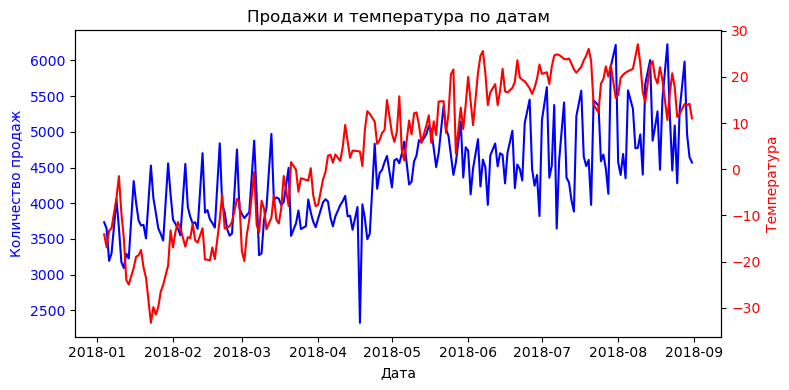

In [32]:
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(merged_df['Дата'], merged_df['Количество'], label='Количество продаж', color='b')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество продаж', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(merged_df['Дата'], merged_df['T'], label='Температура', color='r')
ax2.set_ylabel('Температура', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Продажи и температура по датам')
fig.tight_layout()
plt.show()

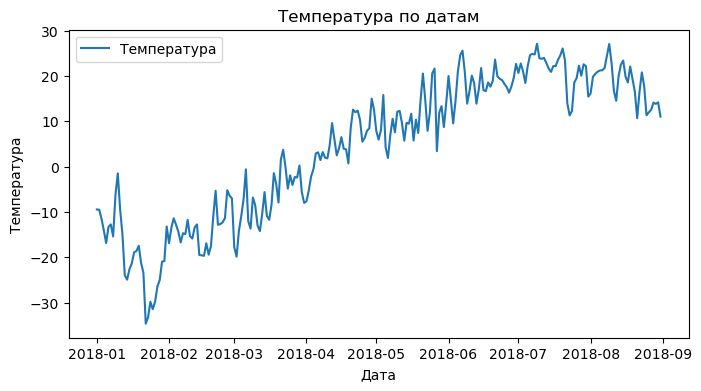

In [34]:
plt.figure(figsize=(8, 4))
plt.plot(df_weather['Дата'], df_weather['T'], label='Температура')
plt.title('Температура по датам')
plt.xlabel('Дата')
plt.ylabel('Температура')
plt.legend()
plt.show()